<a href="https://colab.research.google.com/github/Kieunhungtruong/Econometrics/blob/main/pythonversion/chapter8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display:flex;flex-direction:column;align-items:center;justify-content:center;gap:10px;">
  <h1 style="text-align:center;font-size:26px;font-weight:bold;font-family:'Nunito';color:purple;">
    Chapter 8 – Hồi quy số liệu đếm (Count Data Models)
  </h1>
</div>

## Kết nối Google Drive và cài gói cần thiết

In [67]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [68]:
!pip install pyreadstat -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2
import pyreadstat

palette = ["#53b0ae", "#a31414", "#2b6999", "#e37000", "#b2c615", "#88837d", "#B3B3B3"]

## Đọc dữ liệu

In [69]:
df, meta = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/remittances_adolescents.dta",
    encoding="latin1",
)
df.head()

,tinh,huyen,xa,diaban,hoso,adolescent_gender,m1ama1,HHsize,adolescent6_18_ratio,adolescent0_15_ratio,outpatient,inpatient,domestic_remittances,overseas_remittances,remittances,crop_land
0,1,1,22,39,14,1,5,5.0,0.200000,0.200000,1.0,0.0,1.0,0.0,5000.0,0.0
1,1,1,34,10,19,0,3,4.0,0.250000,0.500000,3.0,0.0,1.0,0.0,15000.0,0.0
2,1,2,55,14,19,1,4,4.0,0.500000,0.500000,1.0,0.0,1.0,0.0,4500.0,0.0
3,1,2,67,16,14,1,3,4.0,0.250000,0.500000,3.0,0.0,1.0,0.0,8000.0,0.0
4,1,2,67,16,15,1,3,3.0,0.333333,0.333333,1.0,0.0,1.0,0.0,2000.0,0.0


---
# 8.1 Số liệu đếm là gì?

Có nhiều hiện tượng trong đó biến phụ thuộc có dạng số đếm, chẳng hạn:
- Số lượng bằng sáng chế của một công ty trong một năm.
- Số lượng người đến gặp nha sĩ trong một năm.
- Số lượng vé phạt do quá tốc độ trong một năm.

Các biến này có dạng **rời rạc**, chỉ nhận giá trị hữu hạn không âm (finite non-negative). Số liệu dạng này có nhiều quan sát có giá trị 0.

Hồi quy OLS không phù hợp vì:
- OLS có thể cho ra giá trị dự báo **âm**, trong khi số đếm không bao giờ âm.
- Phần dư thường **không tuân theo phân phối chuẩn** với dữ liệu đếm.
- Biến phụ thuộc thường có **phân phối lệch phải** rõ rệt.

---
# 8.2 Tạo biến tương tác và khai báo biến

Trước khi ước lượng, ta tạo các biến tương tác giữa kiều hối và giới tính của trẻ.

In [70]:
# Tạo biến tương tác
df["overseas_adolescent_gender"] = df["overseas_remittances"] * df["adolescent_gender"]
df["domestic_adolescent_gender"] = df["domestic_remittances"] * df["adolescent_gender"]

# Danh sách biến độc lập
xvars = [
    "adolescent6_18_ratio",
    "adolescent0_15_ratio",
    "HHsize",
    "overseas_remittances",
    "domestic_remittances",
    "overseas_adolescent_gender",
    "domestic_adolescent_gender",
    "crop_land",
]

y = df["outpatient"]
X = sm.add_constant(df[xvars])

print("Số quan sát:", len(df))
print("Biến phụ thuộc: outpatient")
print("Biến độc lập:", xvars)

Số quan sát: 1731
Biến phụ thuộc: outpatient
Biến độc lập: ['adolescent6_18_ratio', 'adolescent0_15_ratio', 'HHsize', 'overseas_remittances', 'domestic_remittances', 'overseas_adolescent_gender', 'domestic_adolescent_gender', 'crop_land']


---
# 8.3 Mô hình hồi quy OLS (Bảng 8.1)

Đầu tiên ta thử dùng OLS để thấy giới hạn của nó với dữ liệu số đếm.

In [71]:
# Hồi quy OLS
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             outpatient   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.582
Date:                Wed, 08 Apr 2026   Prob (F-statistic):            0.00839
Time:                        18:17:44   Log-Likelihood:                -4114.5
No. Observations:                1731   AIC:                             8247.
Df Residuals:                    1722   BIC:                             8296.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Phân phối biến phụ thuộc (Hình 8.1)

Vẽ histogram để quan sát phân phối của biến `outpatient` và mô tả thống kê cơ bản.

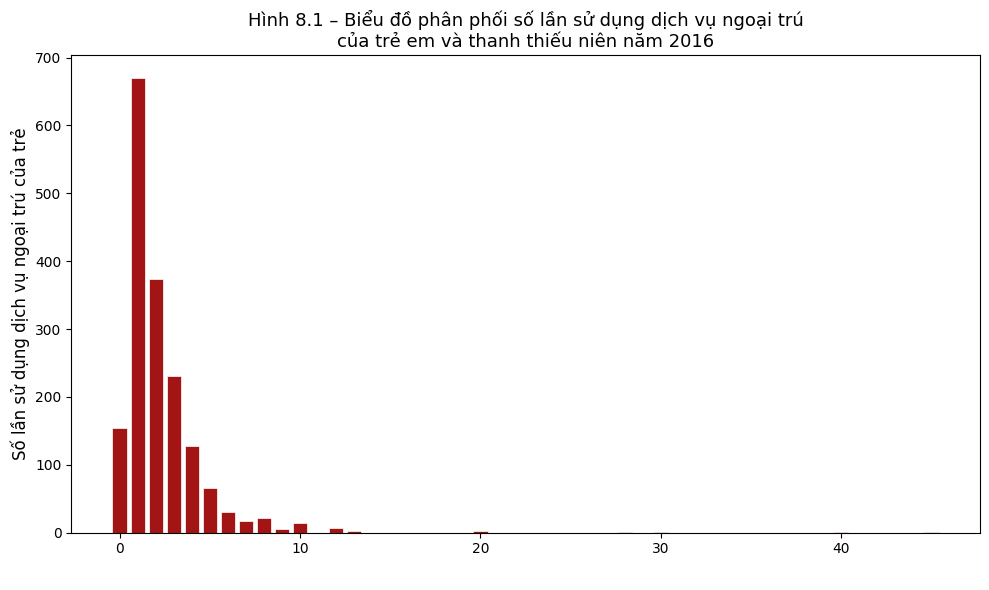

In [72]:
# Histogram phân phối outpatient
plt.figure(figsize=(10, 6))
counts = df["outpatient"].value_counts().sort_index()
plt.bar(counts.index, counts.values, color=palette[1], edgecolor="white", linewidth=0.5)
plt.xlabel(" ", fontsize=12)
plt.ylabel("Số lần sử dụng dịch vụ ngoại trú của trẻ", fontsize=12)
plt.title("Hình 8.1 – Biểu đồ phân phối số lần sử dụng dịch vụ ngoại trú\ncủa trẻ em và thanh thiếu niên năm 2016", fontsize=13)
plt.tight_layout()
plt.show()

In [73]:
# Thống kê mô tả chi tiết
from scipy import stats
print(df["outpatient"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(1))

skew = stats.skew(df["outpatient"].dropna())
kurt = stats.kurtosis(df["outpatient"].dropna(), fisher=False)

print(f"Skewness : {skew:.6f}")
print(f"Kurtosis : {kurt:.6f}")

# Kiểm định Jarque-Bera
jb_stat, jb_p = stats.jarque_bera(df["outpatient"].dropna())
print(f"\nJarque-Bera statistic : {jb_stat:.2f}")
print(f"P-value               : {jb_p:.4f}")
print("→ Bác bỏ H₀ (phân phối chuẩn): biến outpatient KHÔNG tuân theo phân phối chuẩn")

count    1731.0
mean        2.3
std         2.6
min         0.0
1%          0.0
5%          0.0
10%         1.0
25%         1.0
50%         2.0
75%         3.0
90%         4.0
95%         6.0
99%        10.0
max        45.0
Name: outpatient, dtype: float64
Skewness : 6.605876
Kurtosis : 83.074724

Jarque-Bera statistic : 475052.16
P-value               : 0.0000
→ Bác bỏ H₀ (phân phối chuẩn): biến outpatient KHÔNG tuân theo phân phối chuẩn


---
# 8.4 Mô hình hồi quy Poisson (Bảng 8.2)

## Lý thuyết

Nếu biến ngẫu nhiên rời rạc $Y$ theo phân phối Poisson, hàm mật độ xác suất là:

$$f(Y=y_i) = \frac{e^{-\lambda_i} \lambda_i^{y_i}}{y_i!}, \quad y = 0, 1, 2, \ldots$$

**Đặc điểm phân tán đều (equidispersion):** Với phân phối Poisson, giá trị trung bình và phương sai bằng nhau: $E(Y) = Var(Y) = \lambda$.

Hàm hồi quy Poisson:
$$\lambda_i = E(y_i | X_i) = \exp(\beta_1 + \beta_2 X_{2i} + \ldots + \beta_k X_{ki}) = \exp(\beta X)$$

Việc lấy số mũ $\exp(\beta X)$ đảm bảo $\lambda$ luôn dương.

In [74]:
# Hồi quy Poisson
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             outpatient   No. Observations:                 1731
Model:                            GLM   Df Residuals:                     1722
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3619.1
Date:                Wed, 08 Apr 2026   Deviance:                       3155.7
Time:                        18:17:47   Pearson chi2:                 4.94e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.03421
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Diễn giải hệ số hồi quy Poisson

Hệ số hồi quy trong mô hình Poisson được diễn giải như **semi-elasticity**:

$$\frac{\partial \ln \hat{\lambda}}{\partial X_k} = \beta_k$$

Khi $X_k$ tăng 1 đơn vị, log số lần dùng dịch vụ ngoại trú thay đổi $\beta_k$ đơn vị, tương đương số lần dùng dịch vụ thay đổi $(e^{\beta_k} - 1) \times 100\%$.

In [75]:
# Incidence Rate Ratios (IRR) – tương đương lệnh ,irr trong Stata
print("=" * 65)
print("Incidence Rate Ratios (IRR) – Mô hình Poisson")
print("=" * 65)
irr    = np.exp(poisson_model.params)
ci     = np.exp(poisson_model.conf_int())
pvals  = poisson_model.pvalues

irr_df = pd.DataFrame({
    "IRR"   : irr,
    "CI 2.5%" : ci[0],
    "CI 97.5%": ci[1],
    "P>|z|" : pvals,
})
print(irr_df.to_string(float_format="{:.6f}".format))

Incidence Rate Ratios (IRR) – Mô hình Poisson
                                IRR  CI 2.5%  CI 97.5%    P>|z|
const                      3.189064 2.675124  3.801739 0.000000
adolescent6_18_ratio       0.683723 0.533627  0.876037 0.002643
adolescent0_15_ratio       0.952607 0.771705  1.175915 0.651369
HHsize                     1.001434 0.976493  1.027012 0.911326
overseas_remittances       0.982647 0.764520  1.263008 0.891275
domestic_remittances       0.904871 0.828853  0.987860 0.025563
overseas_adolescent_gender 1.410636 1.025590  1.940244 0.034403
domestic_adolescent_gender 0.918084 0.855678  0.985040 0.017330
crop_land                  0.851112 0.796693  0.909247 0.000002


## Tác động biên (Marginal Effects) – Bảng 8.3

Tác động biên tại giá trị trung bình (MEM) được tính bằng:

$$\frac{\partial E(y|X)}{\partial X_k} = \beta_k \cdot \bar{\lambda}$$

trong đó $\bar{\lambda}$ là giá trị dự báo trung bình.

In [83]:
# Marginal Effects giống Stata
mfx = poisson_model.get_margeff(at='mean', dummy=True)

# In bảng kết quả
print("\nBảng 8.3 – Marginal Effects after Poisson (Stata-style)")
print(mfx.summary())


Bảng 8.3 – Marginal Effects after Poisson (Stata-style)
         GLM Marginal Effects        
Dep. Variable:             outpatient
Method:                          dydx
At:                              mean
                                dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
adolescent6_18_ratio          -0.8594      0.286     -3.010      0.003      -1.419      -0.300
adolescent0_15_ratio          -0.1097      0.243     -0.452      0.651      -0.586       0.366
HHsize                         0.0032      0.029      0.111      0.911      -0.054       0.060
overseas_remittances          -0.0392      0.285     -0.138      0.890      -0.597       0.519
domestic_remittances          -0.2336      0.108     -2.161      0.031      -0.446      -0.022
overseas_adolescent_gender     0.9225      0.513      1.800      0.072      -0.082       1.927
domestic_adolescent_gender    -

---
# 8.5 Hạn chế của mô hình Poisson – Kiểm định quá phân tán (Bảng 8.4)

## Lý thuyết

Nếu **phương sai lớn hơn trung bình** thì gọi là **phân tán trội (overdispersion)**. Khi đó mô hình Poisson không còn phù hợp vì:
- Sai số chuẩn của các hệ số bị đánh giá **thấp hơn thực tế**.
- Thống kê $z$ bị **phóng đại**, dễ kết luận sai về ý nghĩa thống kê.

**Kiểm định Cameron & Trivedi (1990):** Hồi quy $(e_i^2 - y_i)$ lên $\hat{y}_i^2$ không có hằng số:
$$e^2_i - y_i = \alpha \hat{y}^2_i + u_i$$
- $H_0: \alpha = 0$ → không có overdispersion (Poisson phù hợp)
- $H_1: \alpha > 0$ → có overdispersion

In [77]:
# Kiểm định quá phân tán (overdispersion test)
yhat  = poisson_model.predict()
yhat2 = yhat ** 2
e     = y - yhat
e2    = e ** 2
diff  = e2 - y

# Hồi quy diff ~ yhat2, không có hằng số
disp_model = sm.OLS(diff, yhat2).fit()
print("Bảng 8.4 – Kiểm định giả thuyết phân tán bằng nhau")
print(disp_model.summary())

alpha_hat = disp_model.params.iloc[0]
p_val     = disp_model.pvalues.iloc[0]
print(f"\nHệ số alpha = {alpha_hat:.4f}  |  P-value = {p_val:.4f}")
if p_val < 0.05:
    print("→ Có overdispersion: bác bỏ H₀ → Mô hình Poisson KHÔNG phù hợp")
else:
    print("→ Không có overdispersion: chấp nhận H₀ → Mô hình Poisson phù hợp")

Bảng 8.4 – Kiểm định giả thuyết phân tán bằng nhau
                                 OLS Regression Results                                
Dep. Variable:             outpatient   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):              0.007
Method:                 Least Squares   F-statistic:                              12.35
Date:                Wed, 08 Apr 2026   Prob (F-statistic):                    0.000451
Time:                        18:17:47   Log-Likelihood:                         -9528.4
No. Observations:                1731   AIC:                                  1.906e+04
Df Residuals:                    1730   BIC:                                  1.906e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025   

---
# 8.6 Mô hình hồi quy nhị phân âm (Negative Binomial – Bảng 8.5)

## Lý thuyết

Phân phối nhị phân âm có phương sai:

$$\sigma^2 = \mu + \frac{\mu^2}{r}, \quad \mu > 0, r > 0$$

trong đó $\mu$ là trung bình và $r$ là tham số hình dạng. Phương sai luôn **lớn hơn** giá trị trung bình, phù hợp với dữ liệu overdispersed.

Khi $r \to \infty$, NBRM hội tụ về Poisson.

Tham số $\alpha = 1/r$ (alpha) đo mức độ phân tán trội:
- $\alpha = 0$ → Poisson
- $\alpha > 0$ → overdispersion

In [78]:
# Hồi quy Negative Binomial – dùng sm.NegativeBinomial (ước lượng alpha từ dữ liệu)
nbreg_model = sm.NegativeBinomial(y, X).fit(disp=False)
print("Bảng 8.5 – Hồi quy nhị phân âm (NBREG)")
print(nbreg_model.summary())
# In thêm alpha – alpha trong statsmodels = alpha trong Stata
alpha_val = nbreg_model.params['alpha']
print(f"\nalpha (overdispersion) = {alpha_val:.7f}")
print(f"LR test alpha=0: LR chi2(1) = {2*(nbreg_model.llf - (sm.Poisson(y, X).fit(disp=False).llf)):.2f}")

Bảng 8.5 – Hồi quy nhị phân âm (NBREG)
                     NegativeBinomial Regression Results                      
Dep. Variable:             outpatient   No. Observations:                 1731
Model:               NegativeBinomial   Df Residuals:                     1722
Method:                           MLE   Df Model:                            8
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                0.005037
Time:                        18:17:48   Log-Likelihood:                -3326.3
converged:                       True   LL-Null:                       -3343.1
Covariance Type:            nonrobust   LLR p-value:                 4.647e-05
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.1612      0.121      9.568      0.000       0.923       1.399
adolescent6_18_ratio          -0.3862      0

In [79]:
# IRR của mô hình Negative Binomial
print("=" * 65)
print("Incidence Rate Ratios (IRR) – Mô hình Negative Binomial")
print("=" * 65)

# Lấy params không bao gồm alpha (param cuối)
params_nb_main = nbreg_model.params[:-1]   # bỏ 'alpha'
ci_nb    = nbreg_model.conf_int().iloc[:-1]
pvals_nb = nbreg_model.pvalues[:-1]

irr_nb   = np.exp(params_nb_main)
ci_nb_exp = np.exp(ci_nb)

irr_nb_df = pd.DataFrame({
    "IRR"     : irr_nb,
    "CI 2.5%" : ci_nb_exp.iloc[:, 0],
    "CI 97.5%": ci_nb_exp.iloc[:, 1],
    "P>|z|"   : pvals_nb,
})
print(irr_nb_df.to_string(float_format="{:.6f}".format))




Incidence Rate Ratios (IRR) – Mô hình Negative Binomial
                                IRR  CI 2.5%  CI 97.5%    P>|z|
const                      3.193738 2.517621  4.051429 0.000000
adolescent6_18_ratio       0.679627 0.486781  0.948873 0.023318
adolescent0_15_ratio       0.956650 0.718420  1.273878 0.761659
HHsize                     1.002768 0.969663  1.037003 0.871811
overseas_remittances       0.977762 0.696410  1.372780 0.896646
domestic_remittances       0.899885 0.798621  1.013989 0.083295
overseas_adolescent_gender 1.403793 0.901001  2.187162 0.133827
domestic_adolescent_gender 0.916807 0.835004  1.006623 0.068526
crop_land                  0.847954 0.776654  0.925801 0.000233


## Tác động biên của mô hình nhị phân âm (Bảng 8.6)

In [84]:
# Marginal effects – Negative Binomial
from scipy import stats
mfx1 = nbreg_model.get_margeff(at='mean', method='dydx', dummy=True)
print("\nBảng 8.6 – Marginal Effects after Negative Binomial")
print(mfx1.summary())


Bảng 8.6 – Marginal Effects after Negative Binomial
  NegativeBinomial Marginal Effects  
Dep. Variable:             outpatient
Method:                          dydx
At:                              mean
                                dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
adolescent6_18_ratio          -0.8729      0.385     -2.268      0.023      -1.627      -0.119
adolescent0_15_ratio          -0.1002      0.330     -0.303      0.762      -0.747       0.547
HHsize                         0.0062      0.039      0.161      0.872      -0.070       0.082
overseas_remittances          -0.0503      0.383     -0.131      0.896      -0.801       0.701
domestic_remittances          -0.2470      0.148     -1.672      0.094      -0.536       0.042
overseas_adolescent_gender     0.9071      0.710      1.278      0.201      -0.484       2.298
domestic_adolescent_gender    -0.19

---
# 8.7 Kiểm định sự phù hợp: Poisson vs. Nhị phân âm

## Likelihood Ratio Test (LR Test)

Kiểm định LR so sánh log-likelihood của hai mô hình lồng nhau:

$$LR = 2(\ell_{NBREG} - \ell_{Poisson}) \sim \chi^2(1)$$

- $H_0: \alpha = 0$ → Poisson phù hợp
- $H_1: \alpha > 0$ → NBREG phù hợp hơn

In [81]:
# Likelihood Ratio Test: Poisson vs Negative Binomial
from scipy.stats import chi2

ll_poisson = poisson_model.llf
ll_nbreg   = nbreg_model.llf

LR_stat = 2 * (ll_nbreg - ll_poisson)
p_lr    = 1 - chi2.cdf(LR_stat, df=1)

print("Likelihood-Ratio Test: Poisson nested within Negative Binomial")
print("-" * 55)
print(f"Log-likelihood Poisson      : {ll_poisson:.4f}")
print(f"Log-likelihood Neg. Binomial: {ll_nbreg:.4f}")
print(f"LR chi2(1)                  : {LR_stat:.2f}")
print(f"Prob > chi2                 : {p_lr:.4f}")

if p_lr < 0.05:
    print("\n→ Bác bỏ H₀: Mô hình Negative Binomial PHÙ HỢP HƠN Poisson")
else:
    print("\n→ Không bác bỏ H₀: Mô hình Poisson phù hợp")

Likelihood-Ratio Test: Poisson nested within Negative Binomial
-------------------------------------------------------
Log-likelihood Poisson      : -3619.0688
Log-likelihood Neg. Binomial: -3326.2636
LR chi2(1)                  : 585.61
Prob > chi2                 : 0.0000

→ Bác bỏ H₀: Mô hình Negative Binomial PHÙ HỢP HƠN Poisson


---
# 8.8 So sánh kết quả ba mô hình: OLS, Poisson, và Negative Binomial

In [82]:
# Bảng tóm tắt so sánh ba mô hình
params_ols  = ols_model.params
se_ols      = ols_model.bse
params_pois = poisson_model.params
se_pois     = poisson_model.bse

vars_to_show = xvars  # bỏ const

comparison = pd.DataFrame(index=vars_to_show)
comparison["OLS Coef"]    = params_ols[vars_to_show]
comparison["OLS SE"]      = se_ols[vars_to_show]
comparison["Poisson Coef"]= params_pois[vars_to_show]
comparison["Poisson SE"]  = se_pois[vars_to_show]
comparison["NBREG Coef"]  = params_nb_main[vars_to_show]
comparison["NBREG SE"]    = nbreg_model.bse[:-1][vars_to_show]

print("Bảng so sánh hệ số hồi quy: OLS | Poisson | Negative Binomial")
print("=" * 85)
print(comparison.to_string(float_format="{:.4f}".format))

print("\n--- Thống kê mô hình ---")
print(f"OLS   : R² = {ols_model.rsquared:.4f}")
print(f"Poisson: Log-Lik = {poisson_model.llf:.2f}, Pseudo R² = {1 - poisson_model.llf/poisson_model.llnull:.4f}")
# NBREG pseudo R² = McFadden
print(f"NBREG  : Log-Lik = {nbreg_model.llf:.2f}, Pseudo R² = {nbreg_model.prsquared:.4f}")

Bảng so sánh hệ số hồi quy: OLS | Poisson | Negative Binomial
                            OLS Coef  OLS SE  Poisson Coef  Poisson SE  NBREG Coef  NBREG SE
adolescent6_18_ratio         -0.8773  0.4981       -0.3802      0.1265     -0.3862    0.1703
adolescent0_15_ratio         -0.1077  0.4246       -0.0486      0.1075     -0.0443    0.1461
HHsize                        0.0034  0.0506        0.0014      0.0129      0.0028    0.0171
overseas_remittances         -0.0444  0.5209       -0.0175      0.1281     -0.0225    0.1731
domestic_remittances         -0.2402  0.1827       -0.1000      0.0448     -0.1055    0.0609
overseas_adolescent_gender    0.9585  0.7027        0.3440      0.1626      0.3392    0.2262
domestic_adolescent_gender   -0.1931  0.1397       -0.0855      0.0359     -0.0869    0.0477
crop_land                    -0.3621  0.1305       -0.1612      0.0337     -0.1649    0.0448

--- Thống kê mô hình ---
OLS   : R² = 0.0119
Poisson: Log-Lik = -3619.07, Pseudo R² = 0.0083
NBREG  

---
# 8.9 Tóm tắt kết luận

| Tiêu chí | OLS | Poisson | Negative Binomial |
|---|---|---|---|
| Phù hợp với số đếm | ❌ | ✅ | ✅ |
| Xử lý overdispersion | ❌ | ❌ | ✅ |
| Dự báo luôn dương | ❌ | ✅ | ✅ |
| Log-likelihood | N/A | -3,619 | **-3,326** |

**Kết luận:**
1. Biến `outpatient` (số lần khám ngoại trú) không tuân theo phân phối chuẩn (JB test bác bỏ $H_0$).
2. Mô hình Poisson tốt hơn OLS cho dữ liệu đếm, nhưng kiểm định Cameron-Trivedi cho thấy **có overdispersion** (hệ số alpha có ý nghĩa thống kê).
3. **Mô hình Negative Binomial là lựa chọn phù hợp nhất**: LR test bác bỏ $H_0$ với $LR = 585.61$, $p < 0.001$.
4. Biến `crop_land` và `domestic_remittances` có tác động tiêu cực đến số lần dùng dịch vụ ngoại trú của trẻ em và thanh thiếu niên.

Lưu ý:
1. Sử dụng `pyreadstat` thay vì `pandas.read_stata()` vì đọc file `.dta` nhanh hơn, giữ được label và metadata đầy đủ.
2. Mô hình Poisson dùng `sm.GLM(..., family=sm.families.Poisson())` – tương đương lệnh `poisson` trong Stata.
3. **Quan trọng:** Mô hình Negative Binomial dùng `sm.NegativeBinomial(y, X).fit()` (từ `statsmodels.discrete.discrete_model`) chứ KHÔNG dùng `sm.GLM(..., family=NegativeBinomial())`. Lý do: `GLM` version dùng alpha cố định (mặc định alpha=1.0), trong khi `sm.NegativeBinomial` ước lượng alpha từ dữ liệu (MLE) – tương đương `nbreg` trong Stata.
4. Tham số `lnalpha` trong statsmodels: `alpha = exp(lnalpha)` tương ứng với `alpha` trong Stata. LR test alpha=0 xác nhận cần dùng NBREG.
5. Marginal effects được tính theo công thức MEM (at the mean), kết quả có thể chênh lệch nhỏ so với Stata do cách tính nội bộ các gói thống kê.

<h2 style="font-size: 26px; font-weight: bold; font-family:'Nunito'; color: purple;">About the Authors:</h2>

<a href="https://www.linkedin.com/in/truongnhung2002"> Nhung Truong (Kristen Zhang) </a> has a degree in Investment Economics from UEH, with a focus on quantitative research.

### <h3 align="center"> © 2026 Nhung Truong. Licensed under CC BY 4.0 </h3>